## Level 1

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("Dataset.csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [8]:
# NAmes of rows and columns:
df.shape

(9551, 21)

### Task1: Top Cuisines

#### Determine the top three most common cusines

In [11]:
cuisine_count=df['Cuisines'].str.split(',',).explode().value_counts()
top_three_cuisine=cuisine_count.head(3)
print(top_three_cuisine)

Cuisines
North Indian    2992
 Chinese        1880
 Fast Food      1314
Name: count, dtype: int64


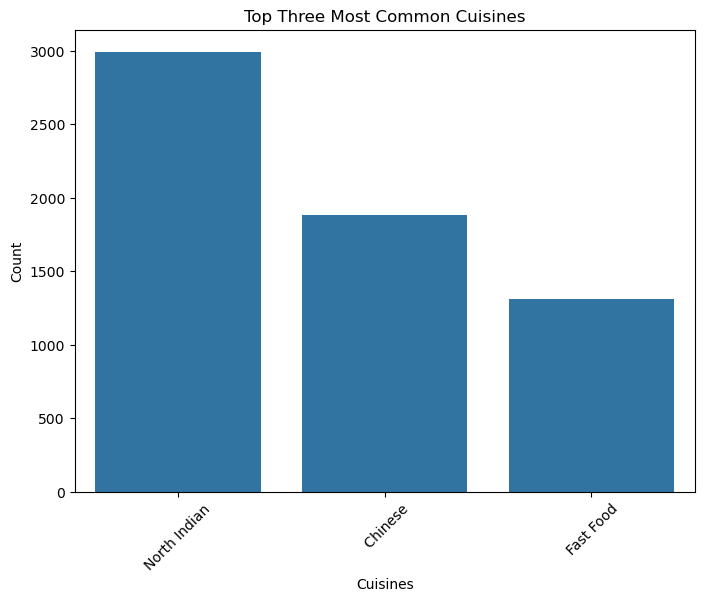

In [15]:
top_three_cuisine=top_three_cuisine.sort_values(ascending=False)
fig,Ax=plt.subplots(figsize=(8,6))
sns.barplot(x=top_three_cuisine.index,y=top_three_cuisine.values,ax=Ax)
plt.title('Top Three Most Common Cuisines')
plt.xlabel('Cuisines')
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()
           

#### Calculate the percentage of restaurants that serve each of the top cuisines..

In [21]:
top_restaurants = len(df)

percentage_per_cuisine = (top_three_cuisine / top_restaurants) * 100

print(percentage_per_cuisine)

Cuisines
North Indian    31.326563
 Chinese        19.683803
 Fast Food      13.757722
Name: count, dtype: float64


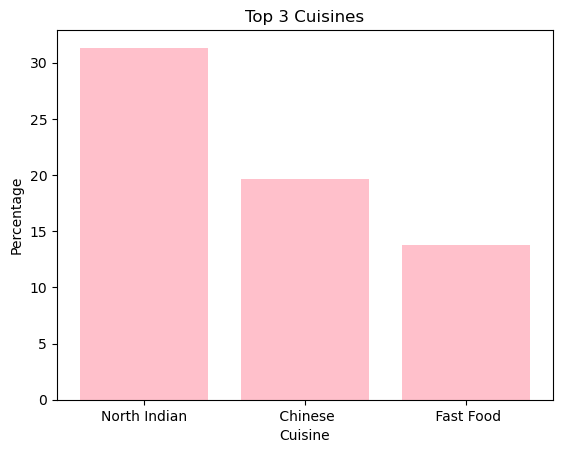

In [22]:
plt.bar(percentage_per_cuisine.index, percentage_per_cuisine.values, color='pink')

plt.xlabel("Cuisine")
plt.ylabel("Percentage")
plt.title("Top 3 Cuisines")

plt.show()

### Task2 : City Analysis
#### Identify the city with highest numbers of resturants in the dataset

In [4]:
print(df['City'].value_counts()[[0]].index[0])

New Delhi


C:\Users\Varsha M\AppData\Local\Temp\ipykernel_12080\1089734477.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df['City'].value_counts()[[0]].index[0])


#### Calculate the average for resturants in each day

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("Dataset.csv")
avg_restaurent=df.groupby('City').agg(Average_rating=('Aggregate rating','mean')).sort_values(by='Average_rating')
print(avg_restaurent)

                  Average_rating
City                            
Faridabad               1.866932
Noida                   2.036204
Mc Millan               2.400000
Montville               2.400000
New Delhi               2.438845
...                          ...
Mandaluyong City        4.625000
Pasig City              4.633333
Makati City             4.650000
Quezon City             4.800000
Inner City              4.900000

[141 rows x 1 columns]


#### Determine the city with the highest average rating.

In [8]:
avg_restaurent=df.groupby('City').agg(Average_rating=('Aggregate rating','mean')).sort_values(by='Average_rating')
print('the city with the highest average rating is',avg_restaurent.index[0])

the city with the highest average rating is Faridabad


### Task3 : Price Range Distribution
#### Create a histogram or bar chart to visualize the price ranges among the restaurants.

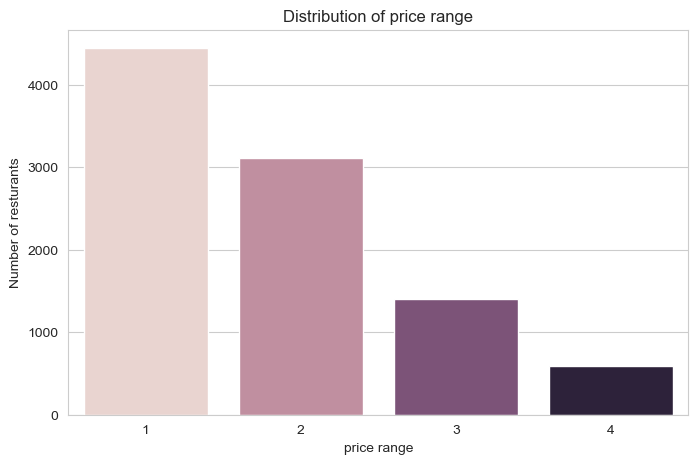

In [17]:
price_range=df['Price range'].value_counts().sort_index()
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))
sns.barplot(x=price_range.index,y=price_range.values,hue=price_range.index,legend=False)
plt.xlabel("price range")
plt.ylabel("Number of resturants")
plt.title("Distribution of price range")
plt.show()

#### Calculate the percentage of restaurants in each price range category.

In [19]:
price_range=df["Price range"].value_counts()
total_restaurant=len(df)
percentage=round((price_range/total_restaurant)*100,2)
percentage_n=pd.merge(price_range,percentage,on="Price range")
print("The % of resturants in each price range category are:",percentage_n)

The % of resturants in each price range category are:              count_x  count_y
Price range                  
1               4444    46.53
2               3113    32.59
3               1408    14.74
4                586     6.14


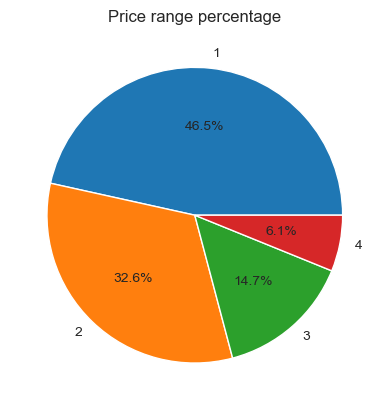

In [22]:
plt.pie(percentage,labels=percentage.index,autopct='%1.1f%%')
plt.title("Price range percentage")
plt.show()

### Task4: Online Delivery
#### Determine the percentage of restaurants that offer online delivery.

In [23]:
print(df.columns)

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')


In [27]:
online_delivery = df['Has Online delivery'].value_counts().get('Yes', 0)
print("Total restaurants with online delivery:", online_delivery)

Total restaurants with online delivery: 2451


In [28]:
no_online_delivery = df['Has Online delivery'].value_counts().get('No', 0)
print("Total restaurants with online delivery:", no_online_delivery)

Total restaurants with online delivery: 7100


In [29]:
Row_count=len(df)
percentage_of_online_delivery=round((online_delivery/Row_count)*100,2)
print("total % of online Delivery:", percentage_of_online_delivery)

total % of online Delivery: 25.66


In [31]:
percentage_of_no_online_delivery=round((no_online_delivery/Row_count)*100,2)
print("total % of online Delivery:", percentage_of_no_online_delivery)

total % of online Delivery: 74.34


#### Compare the average ratings of restaurants with and without online delivery..

In [33]:
Avg_rating_yes=round(df[df['Has Online delivery']=='Yes']['Aggregate rating'].mean(),2)
print("Average rating with online rating delivery :",Avg_rating_yes)

Average rating with online rating delivery : 3.25


In [34]:
Avg_rating_no=round(df[df['Has Online delivery']=='No']['Aggregate rating'].mean(),2)
print("Average rating with online rating delivery :",Avg_rating_no)

Average rating with online rating delivery : 2.47


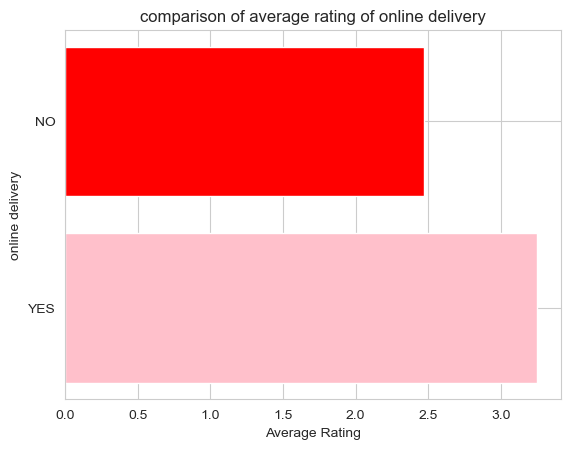

In [37]:
labels=['YES','NO']
average_rating=[Avg_rating_yes,Avg_rating_no]
colurs=["pink","red"]
plt.barh(labels,average_rating,color=colurs)
plt.ylabel('online delivery')
plt.xlabel('Average Rating')
plt.title('comparison of average rating of online delivery')
plt.show()
           

## Level 2

### Task1 : Restaurant Ratings
#### Analyze the distribution of aggregate ratings and determine the most common rating range.

In [39]:
agg_rating_distribution=df['Aggregate rating'].value_counts()
print(agg_rating_distribution)

Aggregate rating
0.0    2148
3.2     522
3.1     519
3.4     498
3.3     483
3.5     480
3.0     468
3.6     458
3.7     427
3.8     400
2.9     381
3.9     335
2.8     315
4.1     274
4.0     266
2.7     250
4.2     221
2.6     191
4.3     174
4.4     144
2.5     110
4.5      95
2.4      87
4.6      78
4.9      61
2.3      47
4.7      42
2.2      27
4.8      25
2.1      15
2.0       7
1.9       2
1.8       1
Name: count, dtype: int64


In [43]:
a=agg_rating_distribution.idxmax()
print("most common rating range is : " ,a)

most common rating range is :  0.0


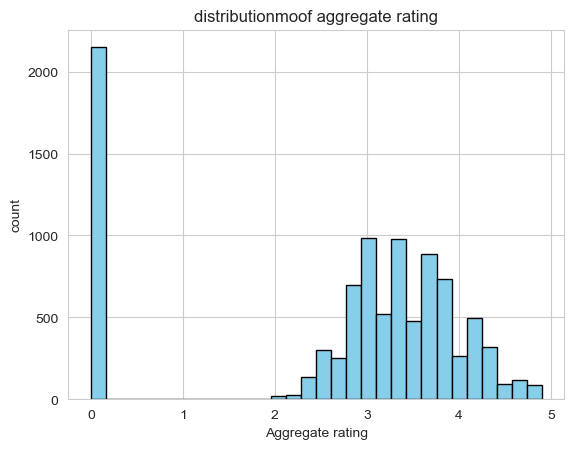

In [45]:
plt.hist(df['Aggregate rating'],bins=30,color='skyblue',edgecolor='black')
plt.xlabel("Aggregate rating")
plt.ylabel("count")
plt.title("distributionmoof aggregate rating")
plt.show()

#### Calculate the average number of votes received by restaurants.

In [47]:
avg_vote=round(df['Votes'].mean(),3)
print("The average number of votes received by restuarants:",avg_vote)

The average number of votes received by restuarants: 156.91


### Task2 : Cuisine Combination
#### Identify the most common combinations of cuisines in the dataset.

In [49]:
common_combinations=df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False)
top10=common_combinations.head(10)
print("top 10 moat common combinations are:",top10)

top 10 moat common combinations are: Cuisines
Italian, Deli               4.9
Hawaiian, Seafood           4.9
American, Sandwich, Tea     4.9
Continental, Indian         4.9
European, Asian, Indian     4.9
European, Contemporary      4.9
European, German            4.9
BBQ, Breakfast, Southern    4.9
American, Coffee and Tea    4.9
Sunda, Indonesian           4.9
Name: Aggregate rating, dtype: float64


#### Determine if certain cuisine combinations tend to have higher ratings..

In [50]:
max_rating=common_combinations.iloc[0]
print("the max rating is: ",max_rating)

the max rating is:  4.9


In [51]:
max_rated_rest=df.loc[df['Aggregate rating']==max_rating]
print("resturants having the maximum rating : ",max_rated_rest['Restaurant Name'])

resturants having the maximum rating :  3                                           Ooma
8       Spiral - Sofitel Philippine Plaza Manila
10                              Silantro Fil-Mex
39                                    Coco Bambu
48                            Braseiro da G��vea
                          ...                   
9484              Restaurant Mosaic @ The Orient
9514                            Ministry of Crab
9524                                Gaga Manjero
9538                                   Starbucks
9540                            Draft Gastro Pub
Name: Restaurant Name, Length: 61, dtype: object


### task3 : Geographic Analysis
#### Plot the locations of restaurants on a map using longitude and latitude coordinates.

In [8]:
pip install geopandas


   ---------------------------------------- 0.0/342.5 kB ? eta -:--:--
   --- ----------------------------------- 30.7/342.5 kB 640.0 kB/s eta 0:00:01
   ------ -------------------------------- 61.4/342.5 kB 656.4 kB/s eta 0:00:01
   -------- ------------------------------ 71.7/342.5 kB 558.5 kB/s eta 0:00:01
   ------------- ------------------------ 122.9/342.5 kB 654.9 kB/s eta 0:00:01
   ----------------- -------------------- 153.6/342.5 kB 654.6 kB/s eta 0:00:01
   ---------------------- --------------- 204.8/342.5 kB 731.4 kB/s eta 0:00:01
   ----------------------- -------------- 215.0/342.5 kB 654.3 kB/s eta 0:00:01
   ------------------------------ ------- 276.5/342.5 kB 739.6 kB/s eta 0:00:01
   ------------------------------- ------ 286.7/342.5 kB 679.3 kB/s eta 0:00:01
   ----------------------------------- -- 317.4/342.5 kB 678.1 kB/s eta 0:00:01
   -------------------------------------- 342.5/342.5 kB 664.5 kB/s eta 0:00:00
   ---------------------------------------- 0.0/

In [11]:
pip install geodatasets

   ---------------------------------------- 0.0/67.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/67.2 kB ? eta -:--:--
   ------ --------------------------------- 10.2/67.2 kB ? eta -:--:--
   ------------------ --------------------- 30.7/67.2 kB 640.0 kB/s eta 0:00:01
   ------------------------ --------------- 41.0/67.2 kB 326.8 kB/s eta 0:00:01
   ------------------------------------ --- 61.4/67.2 kB 326.1 kB/s eta 0:00:01
   ---------------------------------------- 67.2/67.2 kB 302.8 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [14]:
pip install folium



   ---------------------------------------- 0.0/113.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/113.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/113.4 kB ? eta -:--:--
   ------- -------------------------------- 20.5/113.4 kB ? eta -:--:--
   ---------- ----------------------------- 30.7/113.4 kB 1.4 MB/s eta 0:00:01
   ---------- ----------------------------- 30.7/113.4 kB 1.4 MB/s eta 0:00:01
   ----------------- --------------------- 51.2/113.4 kB 327.7 kB/s eta 0:00:01
   ----------------- --------------------- 51.2/113.4 kB 327.7 kB/s eta 0:00:01
   --------------------- ----------------- 61.4/113.4 kB 234.9 kB/s eta 0:00:01
   --------------------- ----------------- 61.4/113.4 kB 234.9 kB/s eta 0:00:01
   ---------------------------- ---------- 81.9/113.4 kB 229.7 kB/s eta 0:00:01
   -------------------------------------  112.6/113.4 kB 285.2 kB/s eta 0:00:01
   -------------------------------------- 113.4/113.4 kB 264.5 kB/s eta 0:00

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas
from geodatasets import get_path
import folium
from folium.plugins import HeatMap
df=pd.read_csv("Dataset.csv")
print(df[["Longitude","Latitude"]])

       Longitude   Latitude
0     121.027535  14.565443
1     121.014101  14.553708
2     121.056831  14.581404
3     121.056475  14.585318
4     121.057508  14.584450
...          ...        ...
9546   28.977392  41.022793
9547   29.041297  41.009847
9548   29.034640  41.055817
9549   29.036019  41.057979
9550   29.026016  40.984776

[9551 rows x 2 columns]


In [22]:
gdf=geopandas.GeoDataFrame(
    df,geometry=geopandas.points_from_xy(df.Longitude,df.Latitude),crs="EPSG:4326"
)

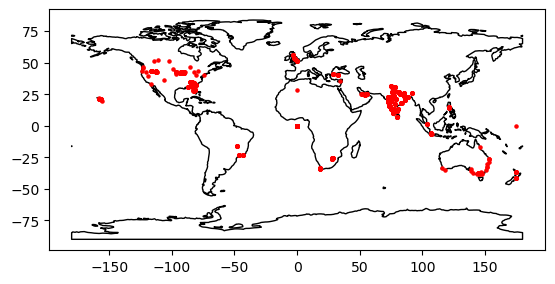

In [24]:
world=geopandas.read_file(get_path("naturalearth.land"))
ax=world.plot(color='white',edgecolor='black')
gdf.plot(ax=ax,marker='o',color='red',markersize=5)
plt.show()

 #### Identify any patterns or clusters of restaurants in specific areas.

In [25]:
world_map=folium.Map(location=[df['Latitude'].mean(),df['Longitude'].mean()],zoom_start=1,height='100%',width='100%')


In [27]:
heat_marker=[[row['Latitude'],row['Longitude']] for i,row in df.iterrows()]
HeatMap(heat_marker,radius=10).add_to(world_map)
world_map

### Task4 : Restaurant Chains
#### Identify if there are any restaurant chains present in the dataset.

In [32]:
restaurant_chain=df.groupby("Restaurant Name").size().reset_index(name="OutletCount")
new=restaurant_chain[restaurant_chain["OutletCount"]>1]
restaurant_chains=new.sort_values(by="OutletCount",ascending=False)
print(restaurant_chains[["Restaurant Name","OutletCount"]].head(10))

       Restaurant Name  OutletCount
1098   Cafe Coffee Day           83
2098    Domino's Pizza           79
6106            Subway           63
2716  Green Chick Chop           51
4077        McDonald's           48
3478         Keventers           34
4961         Pizza Hut           30
2619             Giani           29
680     Baskin Robbins           28
663    Barbeque Nation           26


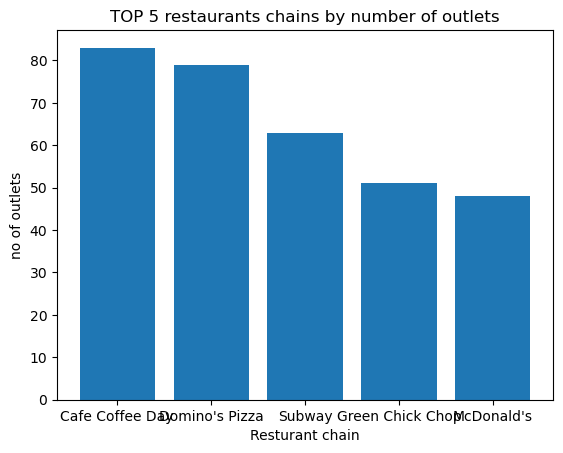

In [35]:
plt.bar(restaurant_chains["Restaurant Name"][:5],restaurant_chains["OutletCount"][:5])
plt.xlabel("Resturant chain")
plt.ylabel("no of outlets")
plt.title("TOP 5 restaurants chains by number of outlets")
plt.show()

 #### Analyze the ratings and popularity of different restaurant chains.


In [38]:
ratings=df.groupby("Restaurant Name")["Aggregate rating"].mean().reset_index(name="Average Rating").sort_values(by="Average Rating",ascending=False)
print(ratings)

                      Restaurant Name  Average Rating
5322   Restaurant Mosaic @ The Orient             4.9
4177                 Ministry of Crab             4.9
4135                            Miann             4.9
5757          Shorts Burger and Shine             4.9
4165                            Milse             4.9
...                               ...             ...
1105                      Cafe Corner             0.0
4905                  Pheva Tandooris             0.0
4913                     Pick & Carry             0.0
1096                     Cafe Brownie             0.0
2292  Famous Parantha and Poori Sabzi             0.0

[7446 rows x 2 columns]


In [40]:
votes=df.groupby("Restaurant Name")["Votes"].sum().reset_index(name="Total Votes").sort_values(by="Total Votes",ascending=False)
print(votes)

                Restaurant Name  Total Votes
663             Barbeque Nation        28142
101   AB's - Absolute Barbecues        13400
6943                       Toit        10934
785                   Big Chill        10853
2297                 Farzi Cafe        10098
...                         ...          ...
4375                  Muncheezz            0
6217            Swiss Gourmessa            0
2110      Dosa and Pizza Corner            0
6215            Sweets n Treats            0
2433               Food Station            0

[7446 rows x 2 columns]


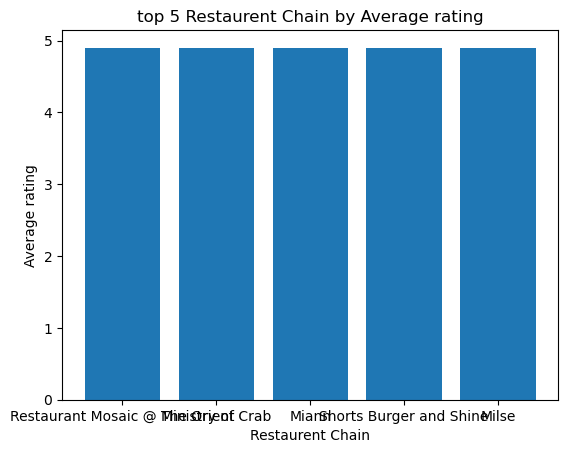

In [46]:
plt.bar(ratings["Restaurant Name"][:5],ratings["Average Rating"][:5])
plt.xlabel("Restaurent Chain")
plt.ylabel("Average rating")
plt.title("top 5 Restaurent Chain by Average rating")
plt.show()

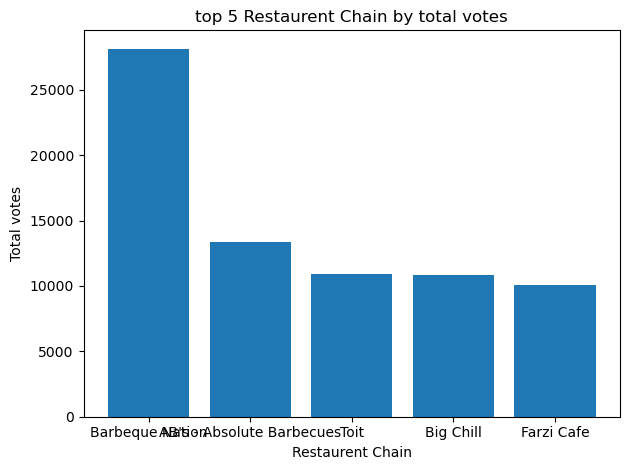

In [47]:
plt.bar(votes["Restaurant Name"][:5],votes["Total Votes"][:5])
plt.xlabel("Restaurent Chain")
plt.ylabel("Total votes")
plt.title("top 5 Restaurent Chain by total votes")
plt.tight_layout()
plt.show()

# Level 3

### Task1 : Restaurant Reviews
#### Analyze the text reviews to identify the most common positive and negative keywords.

In [50]:
print(df['Rating text'])


0       Excellent
1       Excellent
2       Very Good
3       Excellent
4       Excellent
          ...    
9546    Very Good
9547    Very Good
9548         Good
9549    Very Good
9550    Very Good
Name: Rating text, Length: 9551, dtype: object


In [48]:
positive_data=df.loc[df['Aggregate rating']>=2.5]
print(positive_data)

      Restaurant ID           Restaurant Name  Country Code              City  \
0           6317637          Le Petit Souffle           162       Makati City   
1           6304287          Izakaya Kikufuji           162       Makati City   
2           6300002    Heat - Edsa Shangri-La           162  Mandaluyong City   
3           6318506                      Ooma           162  Mandaluyong City   
4           6314302               Sambo Kojin           162  Mandaluyong City   
...             ...                       ...           ...               ...   
9546        5915730               Naml۱ Gurme           208         ��stanbul   
9547        5908749              Ceviz A��ac۱           208         ��stanbul   
9548        5915807                     Huqqa           208         ��stanbul   
9549        5916112               A���k Kahve           208         ��stanbul   
9550        5927402  Walter's Coffee Roastery           208         ��stanbul   

                           

In [51]:
positive_keywords=positive_data['Rating text'].unique()
print(positive_keywords)

['Excellent' 'Very Good' 'Good' 'Average']


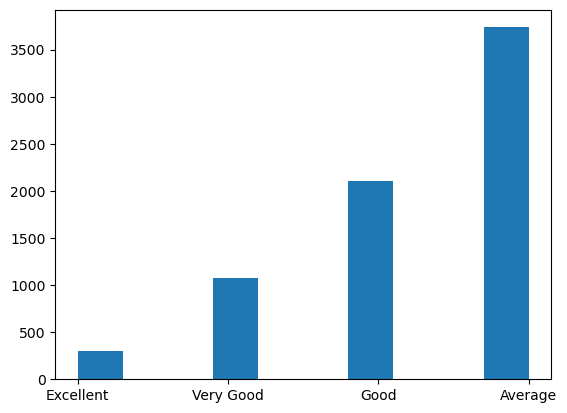

In [53]:
plt.hist(positive_data['Rating text'],label=positive_keywords)
plt.show()

In [55]:
negative_data=df.loc[(df['Aggregate rating']<2.5) & (df['Aggregate rating']>0)]
negative_keywords=negative_data['Rating text'].unique()
print(negative_keywords)

['Poor']


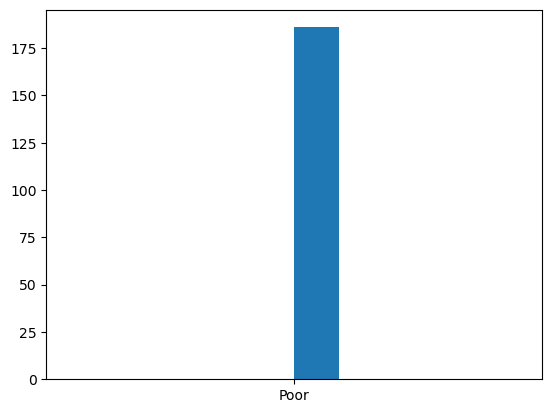

In [57]:
plt.hist(negative_data['Rating text'],label=negative_keywords)
plt.show()

### Task2 : Votes Analysis
#### Identify the restaurants with the highest and lowest number of votes.


In [59]:
Highest_voted_restaurant=df.groupby('Restaurant Name')['Votes'].sum().sort_values(ascending=False)
Highest_voted_restaurant=Highest_voted_restaurant.idxmax()
print("the highest voted restaurant is: ",Highest_voted_restaurant)

the highest voted restaurant is:  Barbeque Nation


In [60]:
lowest_rated_restaurant=df.groupby('Restaurant Name')['Votes'].sum().sort_values()
lowest_rated_restaurant=lowest_rated_restaurant.idxmin()
print("the lowest voted restaurant is:",lowest_rated_restaurant)

the lowest voted restaurant is: Laxmi Food Corner


 #### Analyze if there is a correlation between the number of votes and the rating of a restaurant.

In [62]:
corelation=np.corrcoef(df['Votes'],df['Aggregate rating'])
corelation=np.round(corelation,2)
print(corelation)

[[1.   0.31]
 [0.31 1.  ]]


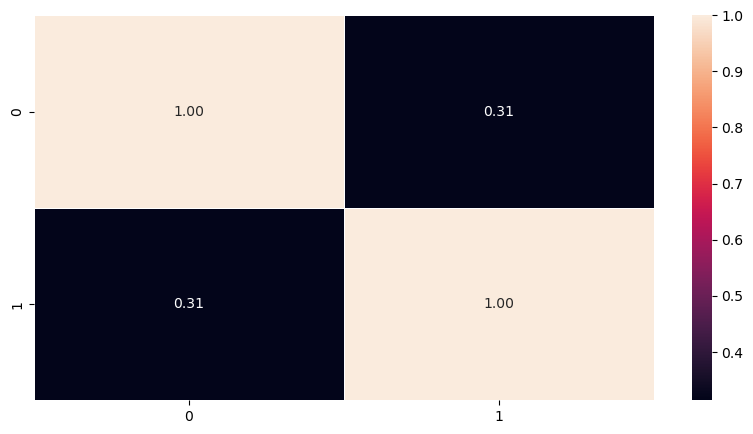

In [64]:
plt.figure(figsize=(10,5),dpi=100)
sns.heatmap(correlation,annot=True,fmt=".2f",linewidth=.4)
plt.show()

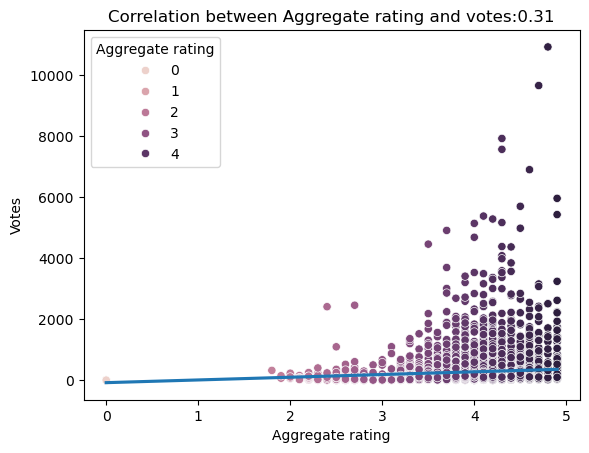

As per result correlationn value=0.31,which indicates there is a moderate positive correlation


In [69]:
sns.scatterplot(data=df,y='Votes',hue='Aggregate rating',x='Aggregate rating')
sns.regplot(data=df,x='Aggregate rating',y='Votes',scatter=False)
plt.title(f"Correlation between Aggregate rating and votes:0.31")
plt.show()
print("As per result correlationn value=0.31,which indicates there is a moderate positive correlation")

### Task3: Price Range vs. Online Delivery and Table Booking#### 

Analyze if there is a relationship between  price range and the availability of online delivery and table bookingteooking.

In [71]:
x1=df['Has Online delivery']
y=df['Average Cost for two']
x2=df['Has Table booking']

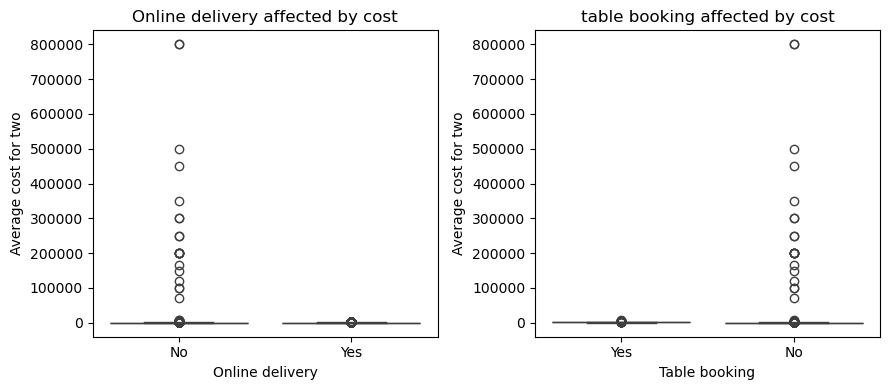

Both the Online delivery and Table booking are negatively impacted by the cost


In [81]:
plt.figure(figsize=(9,4))
plt.subplot(1,2,1)
sns.boxplot(x=x1,y=y)
plt.xlabel('Online delivery')
plt.ylabel('Average cost for two')
plt.title('Online delivery affected by cost')
plt.subplot(1,2,2)
sns.boxplot(x=x2,y=y)
plt.xlabel('Table booking')
plt.ylabel('Average cost for two')
plt.title('table booking affected by cost')
plt.tight_layout()
plt.show()
print("Both the Online delivery and Table booking are negatively impacted by the cost")

#### Determine if higher-priced restaurants are more likely to offer these services.

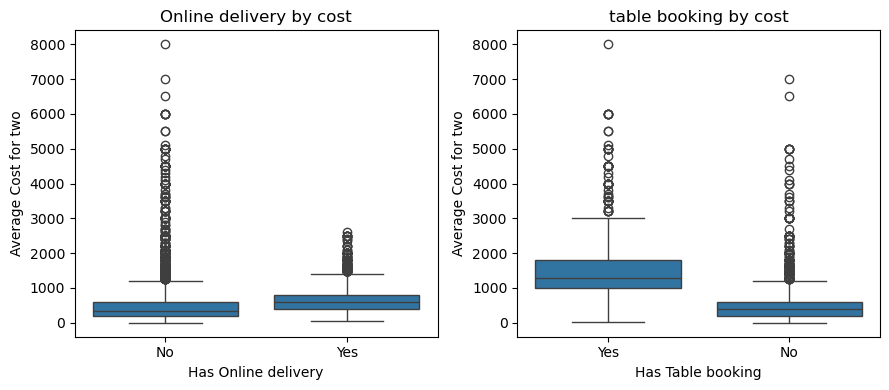

The Online delievry facility is present for only those resturant,where the avg cost is less than 10000
The table booking facility is available in resturants with an average cost rangiong from 1000 to 2000.


In [82]:
plt.figure(figsize=(9,4))
plt.subplot(1,2,1)
sns.boxplot(x=x1,y='Average Cost for two',data=df.loc[df['Average Cost for two']<10000])
plt.title('Online delivery by cost')
plt.subplot(1,2,2)
sns.boxplot(x=x2,y='Average Cost for two' ,data=df.loc[df['Average Cost for two']<10000])
plt.title('table booking by cost')
plt.tight_layout()
plt.show()
print("The Online delievry facility is present for only those resturant,where the avg cost is less than 10000")
print("The table booking facility is available in resturants with an average cost rangiong from 1000 to 2000.")